# Telco Customer Churn Analysis

## 1. Business Understanding

### Objective
The objective of this analysis is to understand customer churn and identify the customer characteristics, services, contract types, and payment methods associated with customer attrition.

### Business Questions
1. What is the overall customer churn rate?
2. Does contract type influence customer churn?
3. Does customer tenure influence churn?
4. Does internet service type influence churn?
5. Does payment method influence churn?
6. Does gender influence churn?
7. Does senior citizen status influence churn?
8. Does having a partner or dependents influence churn?
9. Do monthly and total charges differ between customers who churn and customers who stay?

### Analysis Approach
The analysis includes:
- Data inspection
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Business insights
- Recommendations

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook (Jupyter only)
%matplotlib inline

# Optional: Make plots look nicer
sns.set_style("whitegrid")

In [6]:
df=pd.read_csv('C:\\Users\\elhaa\\Downloads\\Assignment.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [9]:
df.shape

(7043, 21)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"].isnull().sum()

11

In [18]:
df = df.dropna(subset=["TotalCharges"])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [20]:
df.shape

(7032, 21)

## 2. Data Cleaning Summary

- The original dataset contained 7,043 rows and 21 columns.
- `TotalCharges` was stored as an object data type.
- Invalid/blank values in `TotalCharges` were converted to missing values.
- 11 rows with missing `TotalCharges` values were removed.
- The final dataset contains 7,032 rows and 21 columns.
- No duplicate rows were identified.
- The final dataset contains no missing values.
- `TotalCharges` was successfully converted to a numeric data type.

In [21]:
print("Total customers:", len(df))

Total customers: 7032


In [22]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [23]:
df["gender"].value_counts(normalize=True) * 100

gender
Male      50.469283
Female    49.530717
Name: proportion, dtype: float64

In [24]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [25]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [26]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [27]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [28]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [29]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [30]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [31]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

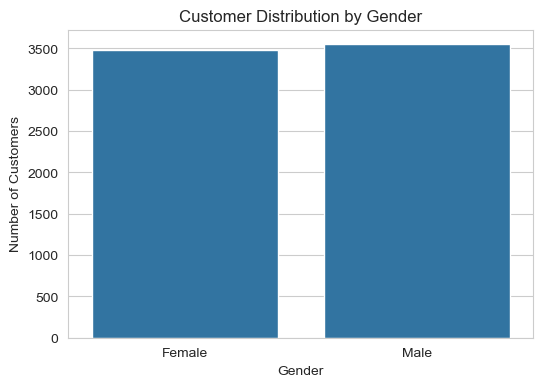

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [33]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


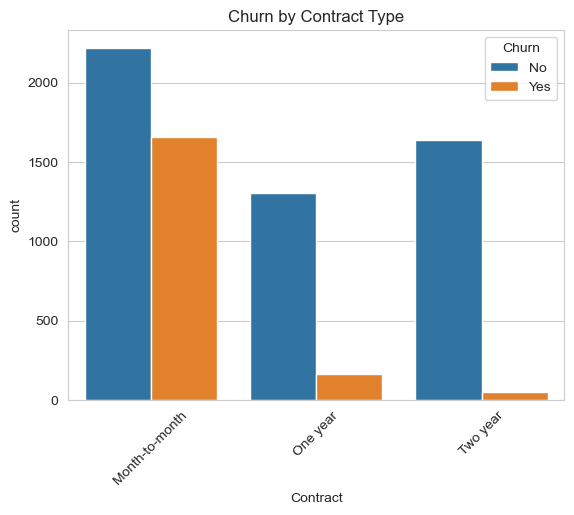

In [34]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

In [36]:
df = df.copy()

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12 Months","13-24 Months","25-48 Months","49-72 Months"]
)

In [37]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

Churn,No,Yes
tenure_group,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


In [38]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


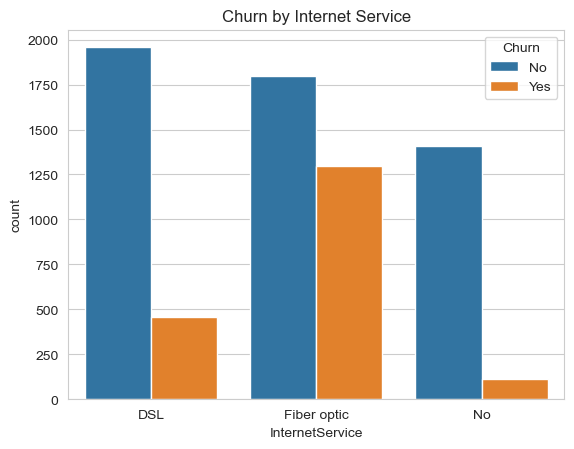

In [39]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

In [40]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [41]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

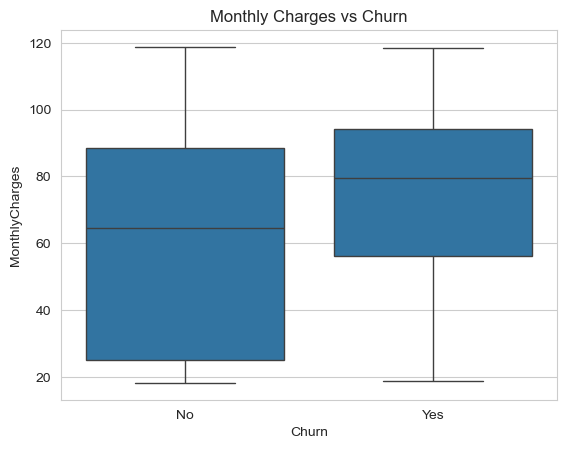

In [42]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

In [43]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [44]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


### Insight

The churn rate is compared between customers who have a partner and those who do not, helping determine whether partner status is associated with customer retention.

In [45]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


### Insight

The churn rate is compared between customers with and without dependents to determine whether dependent status is associated with customer retention.

In [46]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

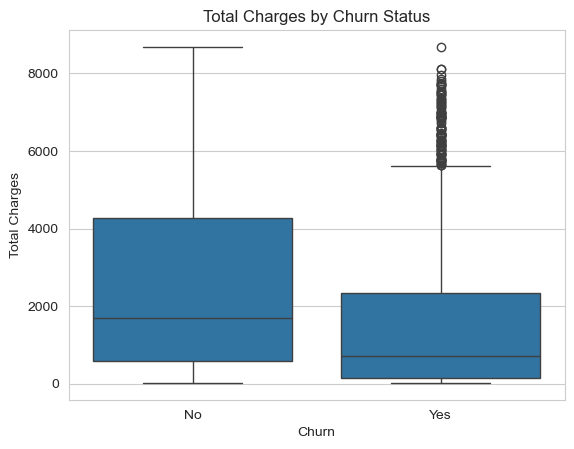

In [47]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [48]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


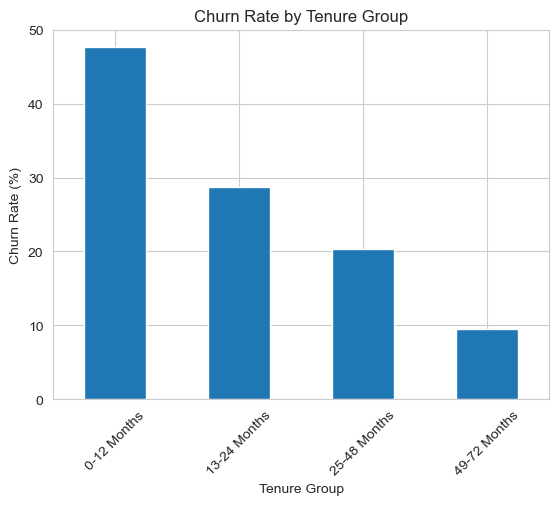

In [49]:
tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

# 3. Key Findings

Based on the exploratory data analysis:

1. The overall customer churn rate is approximately 26.58%.
2. Contract type shows an important relationship with customer churn.
3. Tenure is associated with customer retention, with newer customers representing an important churn-risk segment.
4. Internet service type shows differences in churn rates across customer groups.
5. Payment method shows differences in customer churn rates.
6. Monthly charges differ between customers who churn and customers who remain.
7. Senior citizen, partner, and dependent status can be compared to identify additional customer segments associated with churn.

# 4. Business Recommendations

Based on the findings from the analysis, the company should consider:

1. **Focus on month-to-month customers**
   - Develop incentives that encourage customers to move to longer-term contracts.

2. **Improve early customer retention**
   - Pay particular attention to newer customers during their first months of service.

3. **Investigate high-risk payment methods**
   - Examine why some payment methods have substantially higher churn rates.

4. **Review customers with high monthly charges**
   - Evaluate whether pricing, service quality, or perceived value contributes to churn.

5. **Use customer segmentation**
   - Identify high-risk customer groups and provide targeted retention offers and support.

6. **Monitor churn continuously**
   - Use a dashboard to track churn rate and important customer segments over time.

# 5. Conclusion

This analysis examined customer churn using customer demographics, tenure, contract type, internet service, payment method, and billing information.

The analysis identified customer segments associated with different levels of churn and provided recommendations that can help the business improve customer retention.

The Power BI dashboard provides an interactive visual summary of the main findings.